# SMA Causal Hypothesis Testing Framework
## Does the S&P 500 SMA Signal Causally Drive Forward Returns?

**Context**: The Medium article *Backtesting Ten Basic Moving Averages of S&P 500 — SMA* claims that among windows [10, 20, 50, 100, 200], holding SPX when price is above its N-day SMA generates positive risk-adjusted returns, with SMA-20 producing the best Sharpe (0.72).


---

### Full Pipeline

| Phase | What | Status |
|---|---|---|
| **0 — Data** | Download SPX + VIX from yfinance; compute daily returns | ✅ Complete |
| **1 — Features** | Binary SMA signals × 5 windows; 4 confounders; assemble master df | ✅ Complete |
| 2 — Naive Backtest | Replicate article; compute naive ATE | ✅ Complete |
| 3 — DAG + BIC | 4 candidate graphs; BIC selection | ✅ Complete |
| 4 — Identification | DoWhy identify_effect() per window | ✅ Complete |
| 5 — Causal Battery | 7 estimators: Linear Backdoor, IPW, S/T/X-Learner, Double ML, Causal Forest | ✅ Complete |
| 6 — Robustness | Placebo refutation + window sensitivity | ✅ Complete |
| 7 — Comparison | Master table + forest plot + heatmap | ✅ Complete |
| 8 — Conclusion | Scenario A/B/C: does SMA-20 survive causal scrutiny? | ✅ Complete |

---
## Full Workflow Visual Roadmap

![SMA Causal Hypothesis Testing Workflow](assets/sma_causal_workflow_poster.png)


![image.png](attachment:image.png)

## Strategy

**The core question**: Is the SMA signal's backtest performance *causal*, or is it a spurious correlation with the underlying market regime?

**Data sources**:
- `^GSPC` — S&P 500 daily close via yfinance
- `^VIX` — CBOE Volatility Index daily close via yfinance
- Sample: **2016-03-01 to 2026-03-21** (~2,500 trading days, matching the article's exact period)

**Treatment variables** (one per window):

$$X^{(N)}_t = \mathbf{1}\left[P_t > \text{SMA}_N(t)\right], \quad N \in \{10, 20, 50, 100, 200\}$$

The position on day $t+1$ is $X^{(N)}_t$ (`.shift(1)` to prevent lookahead bias).

**Outcome**:

$$Y_t = \ln\left(\frac{P_{t+5}}{P_t}\right) \quad \text{(5-day forward log return)}$$

**Four confounders** (each causes both treatment and outcome — must be adjusted for):

| Confounder | Definition | Type |
|---|---|---|
| `market_regime` | SPX 100-day return > 0 | Binary |
| `vix_regime` | VIX > 20 | Binary |
| `momentum_20` | SPX 20-day pct change | Continuous |
| `realised_vol` | 20-day rolling SPX vol × √252 | Continuous |

**Focal window**: SMA-20 (article's best Sharpe). All 5 windows run in parallel for comparison.

In [1]:
# Install all packages required for the full pipeline.
# pgmpy  : BIC DAG scoring (Phase 3)
# dowhy  : causal identification + linear backdoor + IPW (Phases 4–5)
# econml : S/T/X-Learner, Double ML, DR-Learner, Causal Forest (Phase 5)
# yfinance: market data (Phase 0)

import subprocess
pkgs = ['pgmpy', 'dowhy', 'econml', 'yfinance', 'scikit-learn']
for pkg in pkgs:
    r = subprocess.run(['pip', 'install', '-q', pkg], capture_output=True, text=True)
    print(f"  {pkg:15s}: {'OK' if r.returncode == 0 else 'FAILED'}")

  pgmpy          : OK
  dowhy          : OK
  econml         : OK
  yfinance       : OK
  scikit-learn   : OK


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
import networkx as nx
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})

# ── Global constants ──────────────────────────────────────────────────────
SEED    = 42
WINDOWS = [10, 20, 50, 100, 200]   # SMA windows from the article
FOCAL   = 20                        # article's best Sharpe window
START   = '2016-03-01'
END     = '2026-03-21'

CONFOUNDER_COLS = ['market_regime', 'vix_regime', 'momentum_20', 'realised_vol']

np.random.seed(SEED)

print("All imports OK.")
print(f"Windows  : {WINDOWS}")
print(f"Focal    : SMA-{FOCAL}")
print(f"Sample   : {START} → {END}")

All imports OK.
Windows  : [10, 20, 50, 100, 200]
Focal    : SMA-20
Sample   : 2016-03-01 → 2026-03-21


---
## Phase 0 — Data Download

Pull S&P 500 (`^GSPC`) and VIX (`^VIX`) daily close prices from Yahoo Finance.
Period is matched exactly to the article's sample (~2,513 trading days).
`auto_adjust=True` handles stock splits automatically.
Daily log return: $r_t = \ln(P_t / P_{t-1})$ — additive over time, symmetric around zero.

In [3]:
# Download S&P 500 and VIX from Yahoo Finance.
# .squeeze() handles newer yfinance MultiIndex output for single-ticker downloads.
# Inner join on common trading dates: aligns SPX and VIX to same calendar.

spx_raw = yf.download('^GSPC', start=START, end=END, auto_adjust=True, progress=False)
vix_raw = yf.download('^VIX',  start=START, end=END, auto_adjust=True, progress=False)

spx_close = spx_raw['Close'].squeeze()
vix_close = vix_raw['Close'].squeeze()

df_raw = pd.DataFrame({'spx': spx_close, 'vix': vix_close}).dropna()

print(f"Rows downloaded    : {len(df_raw):,}")
print(f"Date range         : {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print()
print(df_raw.describe().round(2))

Rows downloaded    : 2,529
Date range         : 2016-03-01 → 2026-03-20

           spx      vix
count  2529.00  2529.00
mean   3865.09    18.45
std    1342.76     7.30
min    1978.35     9.14
25%    2737.80    13.54
50%    3790.38    16.65
75%    4576.73    21.35
max    6978.60    82.69


In [4]:
# Daily log return: r_t = log(P_t / P_{t-1})
# First row = NaN (no prior price) → filled with 0 (no position on day 1).
# prices / returns kept at module level — used throughout all phases.

prices  = df_raw['spx']
returns = np.log(prices / prices.shift(1)).fillna(0)

print("Daily log return statistics:")
print(f"  Mean          : {returns.mean():.6f}   ({returns.mean()*252:.4f} annualised)")
print(f"  Std           : {returns.std():.6f}   ({returns.std()*np.sqrt(252):.4f} annualised)")
print(f"  Min (worst)   : {returns.min():.6f}")
print(f"  Max (best)    : {returns.max():.6f}")
print(f"  Positive days : {(returns > 0).mean():.2%}")

Daily log return statistics:
  Mean          : 0.000471   (0.1186 annualised)
  Std           : 0.011348   (0.1801 annualised)
  Min (worst)   : -0.127652
  Max (best)    : 0.090895
  Positive days : 54.69%


---
## Phase 1 — Feature Engineering

Construct all binary treatment signals and confounders from the raw price data.
Everything in this cell feeds every downstream phase — DAG scoring, DoWhy models, and econml estimators all read from `df`.

**Signal construction** — for each window $N$:

$$X^{(N)}_t = \mathbf{1}\left[P_t > \frac{1}{N}\sum_{k=0}^{N-1} P_{t-k}\right]$$

Note: `.shift(1)` is applied only during backtest simulation (Phase 2), not here.
Storing the raw (unshifted) signal allows feature analysis and DAG scoring on the same day's information set.

**Outcome** — 5-day forward log return:

$$Y_t = \ln\left(\frac{P_{t+5}}{P_t}\right) = \sum_{k=1}^{5} r_{t+k}$$

**Confounder rationale**:

| Confounder | Definition | Confounding mechanism |
|---|---|---|
| `market_regime` | SPX 100d return > 0 | Bull market → signal ON + returns positive |
| `vix_regime` | VIX > 20 | Fear → signal OFF + returns compressed |
| `momentum_20` | SPX 20d pct change | Trend → signal more likely ON + next return positive |
| `realised_vol` | 20d rolling vol × √252 | High vol → signal OFF + return variance inflated |

In [5]:
# SMA signals — one per window, binary, unshifted (shift applied in Phase 2)
sma_signals = {}
for w in WINDOWS:
    sma           = prices.rolling(w).mean()
    sma_signals[w] = (prices > sma).astype(int)
    print(f"  SMA-{w:3d}: signal=1 on {sma_signals[w].mean():.2%} of days")

# Outcome: 5-day forward log return
# shift(-5) aligns the future price to the current row; last 5 rows = NaN
forward_return_5d = np.log(prices.shift(-5) / prices)

# Confounders
market_regime = (prices.pct_change(100) > 0).astype(int)
vix_regime    = (df_raw['vix'] > 20).astype(int)
momentum_20   = prices.pct_change(20)
realised_vol  = returns.rolling(20).std() * np.sqrt(252)

print()
print("NaN audit before dropna:")
for name, s in [('forward_return_5d', forward_return_5d),
                ('market_regime',      market_regime),
                ('vix_regime',         vix_regime),
                ('momentum_20',        momentum_20),
                ('realised_vol',       realised_vol)]:
    print(f"  {name:20s}: {s.isna().sum()} NaNs")

  SMA- 10: signal=1 on 64.25% of days
  SMA- 20: signal=1 on 68.13% of days
  SMA- 50: signal=1 on 71.10% of days
  SMA-100: signal=1 on 75.13% of days
  SMA-200: signal=1 on 75.41% of days

NaN audit before dropna:
  forward_return_5d   : 5 NaNs
  market_regime       : 0 NaNs
  vix_regime          : 0 NaNs
  momentum_20         : 20 NaNs
  realised_vol        : 19 NaNs


In [6]:
# Assemble master dataframe and drop rows with any NaN.
# NaN sources:
#   (a) 200d SMA burn-in  → ~200 rows
#   (b) 100d return burn-in → ~100 rows
#   (c) 20d rolling burn-in → ~20 rows
#   (d) 5d forward shift  → last 5 rows
# dropna() handles all simultaneously.

data = {
    'forward_return_5d': forward_return_5d,
    'market_regime'    : market_regime,
    'vix_regime'       : vix_regime,
    'momentum_20'      : momentum_20,
    'realised_vol'     : realised_vol,
    'vix_raw'          : df_raw['vix'],
}
for w in WINDOWS:
    data[f'sma_signal_{w}'] = sma_signals[w]

df = pd.DataFrame(data).dropna()

# Enforce int dtype on all binary columns
for col in ['market_regime', 'vix_regime'] + [f'sma_signal_{w}' for w in WINDOWS]:
    df[col] = df[col].astype(int)

print(f"Clean observations : {len(df):,}")
print(f"Date range         : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Columns            : {list(df.columns)}")
print()
print("Signal frequencies (% of days signal = 1):")
for w in WINDOWS:
    col = f'sma_signal_{w}'
    freq = df[col].mean()
    print(f"  SMA-{w:3d}: {freq:.2%} invested  |  {1-freq:.2%} out of market")
print()
print("Outcome summary:")
print(f"  E[Y]   = {df['forward_return_5d'].mean():.6f}  (avg 5d fwd log return)")
print(f"  Std[Y] = {df['forward_return_5d'].std():.6f}")

Clean observations : 2,504
Date range         : 2016-03-30 → 2026-03-13
Columns            : ['forward_return_5d', 'market_regime', 'vix_regime', 'momentum_20', 'realised_vol', 'vix_raw', 'sma_signal_10', 'sma_signal_20', 'sma_signal_50', 'sma_signal_100', 'sma_signal_200']

Signal frequencies (% of days signal = 1):
  SMA- 10: 64.46% invested  |  35.54% out of market
  SMA- 20: 68.77% invested  |  31.23% out of market
  SMA- 50: 71.81% invested  |  28.19% out of market
  SMA-100: 75.88% invested  |  24.12% out of market
  SMA-200: 76.04% invested  |  23.96% out of market

Outcome summary:
  E[Y]   = 0.002333  (avg 5d fwd log return)
  Std[Y] = 0.023174


---
## EDA — Visual Overview

Three panels to orient the team before modeling:

1. **SPX price with SMA-20 overlay** — shows how frequently the signal is active, and that signal ON/OFF clusters with regimes
2. **Signal distribution** — bar chart of % days invested per window; shows longer windows = more time invested
3. **Outcome distribution by signal state** — raw (confounded) difference in forward returns between X=1 and X=0; this is the naive ATE that Phase 2 will formalise

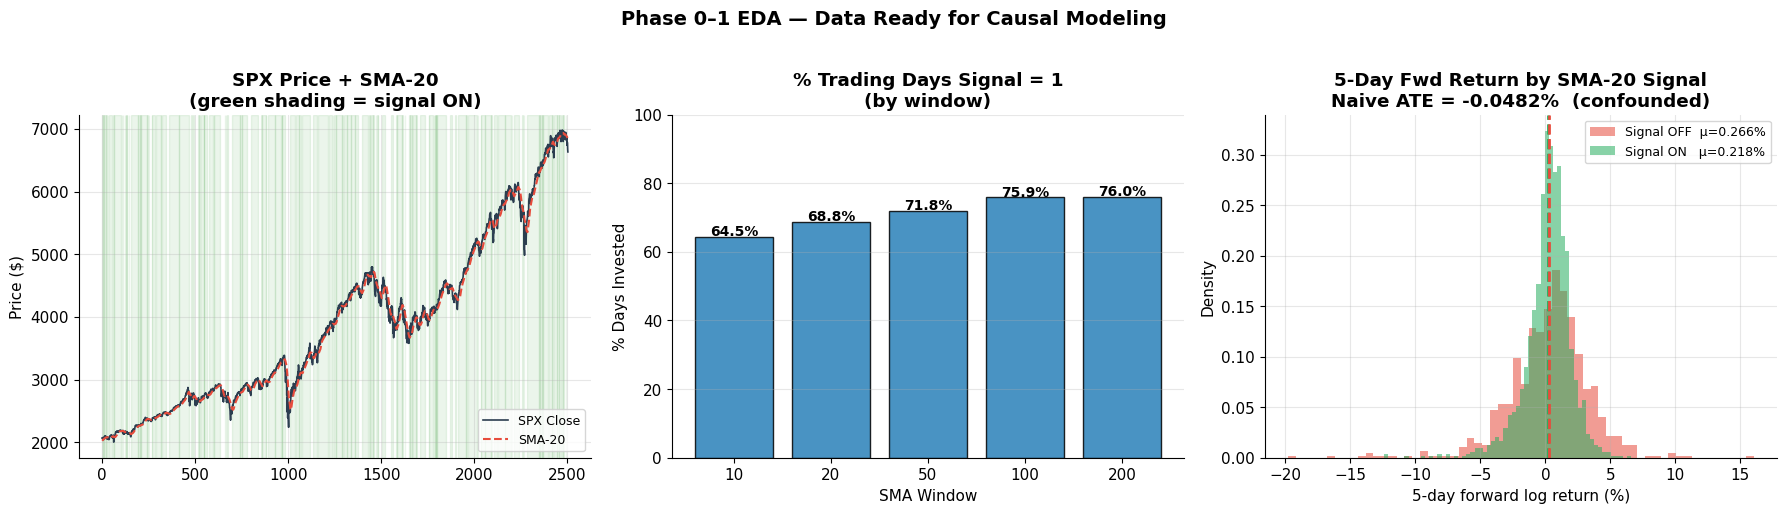

Naive ATE (SMA-20): -0.0482%  ← confounded; causal estimate TBD in Phase 5

df shape: (2504, 11) — ready for Phases 2–8


In [7]:
# EDA: three-panel summary for team discussion.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: SPX price + SMA-20 overlay ──────────────────────────────────
ax = axes[0]
ax.plot(prices.loc[df.index].values, color='#2c3e50', lw=1.2, label='SPX Close')
sma20 = prices.rolling(20).mean().loc[df.index]
ax.plot(sma20.values, color='#e74c3c', lw=1.5, ls='--', label='SMA-20')

# Shade signal-ON regions
sig = df['sma_signal_20']
in_trade = False
start_idx = None
for i, (idx, val) in enumerate(sig.items()):
    if val == 1 and not in_trade:
        start_idx = i; in_trade = True
    elif val == 0 and in_trade:
        ax.axvspan(start_idx, i, alpha=0.08, color='green')
        in_trade = False
if in_trade:
    ax.axvspan(start_idx, len(sig), alpha=0.08, color='green')

ax.set_title('SPX Price + SMA-20\n(green shading = signal ON)', fontweight='bold')
ax.set_ylabel('Price ($)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Panel 2: % days invested per window ──────────────────────────────────
ax = axes[1]
freqs = [df[f'sma_signal_{w}'].mean() * 100 for w in WINDOWS]
bars = ax.bar([str(w) for w in WINDOWS], freqs,
              color='#2980b9', alpha=0.85, edgecolor='black')
for bar, v in zip(bars, freqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('% Trading Days Signal = 1\n(by window)', fontweight='bold')
ax.set_xlabel('SMA Window')
ax.set_ylabel('% Days Invested')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# ── Panel 3: Y distribution by signal state (SMA-20) ─────────────────────
ax = axes[2]
Y  = df['forward_return_5d'] * 100
X  = df['sma_signal_20']
y1 = Y[X == 1]
y0 = Y[X == 0]
ate_naive = y1.mean() - y0.mean()

ax.hist(y0.values, bins=60, alpha=0.55, color='#e74c3c',
        label=f'Signal OFF  μ={y0.mean():.3f}%', density=True)
ax.hist(y1.values, bins=60, alpha=0.55, color='#27ae60',
        label=f'Signal ON   μ={y1.mean():.3f}%', density=True)
ax.axvline(y1.mean(), color='#27ae60', lw=2, ls='--')
ax.axvline(y0.mean(), color='#e74c3c', lw=2, ls='--')
ax.set_title(f'5-Day Fwd Return by SMA-20 Signal\nNaive ATE = {ate_naive:+.4f}%  (confounded)',
             fontweight='bold')
ax.set_xlabel('5-day forward log return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 0–1 EDA — Data Ready for Causal Modeling',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_eda_overview.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Naive ATE (SMA-20): {ate_naive:+.4f}%  ← confounded; causal estimate TBD in Phase 5")
print(f"\ndf shape: {df.shape} — ready for Phases 2–8")

## Phase 2 — Naive Backtest

In [8]:
# ============================================================
# PHASE 2 — NAIVE BACKTEST / NAIVE ATE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def naive_ate_table(df, windows=WINDOWS):
    results = []

    for w in windows:
        treatment_col = f"sma_signal_{w}"
        outcome_col = "forward_return_5d"

        treated = df[df[treatment_col] == 1][outcome_col]
        control = df[df[treatment_col] == 0][outcome_col]

        ate = treated.mean() - control.mean()

        results.append({
            "window": w,
            "treatment": treatment_col,
            "n_treated": len(treated),
            "n_control": len(control),
            "mean_return_signal_on": treated.mean(),
            "mean_return_signal_off": control.mean(),
            "naive_ATE": ate,
            "naive_ATE_pct": ate * 100
        })

    return pd.DataFrame(results)

naive_results = naive_ate_table(df)

print("PHASE 2 — Naive ATE Results")
display(naive_results.round(6))

PHASE 2 — Naive ATE Results


,window,treatment,n_treated,n_control,mean_return_signal_on,mean_return_signal_off,naive_ATE,naive_ATE_pct
0,10,sma_signal_10,1614,890,0.002104,0.002747,-0.000643,-0.064338
1,20,sma_signal_20,1722,782,0.002182,0.002664,-0.000482,-0.048155
2,50,sma_signal_50,1798,706,0.001937,0.003341,-0.001404,-0.140385
3,100,sma_signal_100,1900,604,0.002179,0.002817,-0.000639,-0.063883
4,200,sma_signal_200,1904,600,0.002106,0.003053,-0.000947,-0.094708


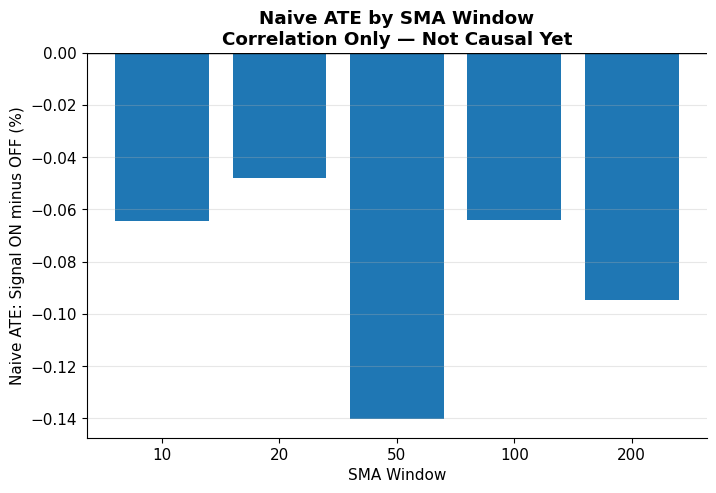

In [9]:
# Plot naive ATE by SMA window

plt.figure(figsize=(8,5))
plt.bar(
    naive_results["window"].astype(str),
    naive_results["naive_ATE_pct"]
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Naive ATE by SMA Window\nCorrelation Only — Not Causal Yet", fontweight="bold")
plt.xlabel("SMA Window")
plt.ylabel("Naive ATE: Signal ON minus OFF (%)")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Phase 3 — Cofounder Identification and DAGS

In [10]:
# ============================================================
# PHASE 3 — DAG CANDIDATES + BIC SELECTION
# ============================================================

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, log_loss
import networkx as nx

OUTCOME = "forward_return_5d"
FOCAL_TREATMENT = f"sma_signal_{FOCAL}"

# We will score DAGs using the focal treatment, SMA-20
dag_data = df[
    [FOCAL_TREATMENT, OUTCOME] + CONFOUNDER_COLS
].copy()

binary_cols = [FOCAL_TREATMENT, "market_regime", "vix_regime"]
continuous_cols = [OUTCOME, "momentum_20", "realised_vol"]


def calculate_node_bic(data, node, parents):
    """
    Computes a simple BIC score for one node given its parents.
    Lower BIC is better.
    Uses logistic regression for binary nodes and linear regression for continuous nodes.
    """

    y = data[node]

    n = len(data)

    # If no parents, use intercept-only model
    if len(parents) == 0:
        k = 1

        if node in binary_cols:
            p = np.clip(y.mean(), 1e-6, 1 - 1e-6)
            ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
            bic = -2 * ll + k * np.log(n)

        else:
            y_pred = np.repeat(y.mean(), n)
            mse = mean_squared_error(y, y_pred)
            mse = max(mse, 1e-12)
            ll = -n / 2 * (np.log(2 * np.pi * mse) + 1)
            bic = -2 * ll + k * np.log(n)

        return bic

    X = data[parents]
    k = X.shape[1] + 1

    if node in binary_cols:
        model = LogisticRegression(max_iter=1000)
        model.fit(X, y)
        prob = model.predict_proba(X)[:, 1]
        ll = -log_loss(y, prob, normalize=False)
        bic = -2 * ll + k * np.log(n)

    else:
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)
        mse = mean_squared_error(y, y_pred)
        mse = max(mse, 1e-12)
        ll = -n / 2 * (np.log(2 * np.pi * mse) + 1)
        bic = -2 * ll + k * np.log(n)

    return bic


def calculate_dag_bic(data, edges):
    """
    Scores entire DAG by summing BIC across every node.
    Lower total BIC = better DAG.
    """

    nodes = list(data.columns)
    total_bic = 0

    for node in nodes:
        parents = [parent for parent, child in edges if child == node]
        total_bic += calculate_node_bic(data, node, parents)

    return total_bic

In [11]:
# Candidate DAGs
# Each DAG is a different causal assumption.

candidate_dags = {
    "DAG 1: Confounders only": [
        ("market_regime", FOCAL_TREATMENT),
        ("vix_regime", FOCAL_TREATMENT),
        ("momentum_20", FOCAL_TREATMENT),
        ("realised_vol", FOCAL_TREATMENT),

        ("market_regime", OUTCOME),
        ("vix_regime", OUTCOME),
        ("momentum_20", OUTCOME),
        ("realised_vol", OUTCOME),

        (FOCAL_TREATMENT, OUTCOME)
    ],

    "DAG 2: Market regime drives everything": [
        ("market_regime", "momentum_20"),
        ("market_regime", "realised_vol"),
        ("market_regime", "vix_regime"),

        ("market_regime", FOCAL_TREATMENT),
        ("vix_regime", FOCAL_TREATMENT),
        ("momentum_20", FOCAL_TREATMENT),
        ("realised_vol", FOCAL_TREATMENT),

        ("market_regime", OUTCOME),
        ("vix_regime", OUTCOME),
        ("momentum_20", OUTCOME),
        ("realised_vol", OUTCOME),

        (FOCAL_TREATMENT, OUTCOME)
    ],

    "DAG 3: Volatility-centered": [
        ("vix_regime", "realised_vol"),
        ("realised_vol", "momentum_20"),

        ("vix_regime", FOCAL_TREATMENT),
        ("realised_vol", FOCAL_TREATMENT),
        ("momentum_20", FOCAL_TREATMENT),
        ("market_regime", FOCAL_TREATMENT),

        ("vix_regime", OUTCOME),
        ("realised_vol", OUTCOME),
        ("momentum_20", OUTCOME),
        ("market_regime", OUTCOME),

        (FOCAL_TREATMENT, OUTCOME)
    ],

    "DAG 4: Full structural assumption": [
        ("market_regime", "momentum_20"),
        ("market_regime", "realised_vol"),
        ("market_regime", "vix_regime"),

        ("vix_regime", "realised_vol"),
        ("momentum_20", "realised_vol"),

        ("market_regime", FOCAL_TREATMENT),
        ("vix_regime", FOCAL_TREATMENT),
        ("momentum_20", FOCAL_TREATMENT),
        ("realised_vol", FOCAL_TREATMENT),

        ("market_regime", OUTCOME),
        ("vix_regime", OUTCOME),
        ("momentum_20", OUTCOME),
        ("realised_vol", OUTCOME),

        (FOCAL_TREATMENT, OUTCOME)
    ]
}

dag_scores = []

for name, edges in candidate_dags.items():
    bic = calculate_dag_bic(dag_data, edges)
    dag_scores.append({
        "dag_name": name,
        "bic_score": bic,
        "num_edges": len(edges)
    })

dag_scores = pd.DataFrame(dag_scores).sort_values("bic_score")

print("PHASE 3 — DAG BIC Scores")
display(dag_scores.round(2))

best_dag_name = dag_scores.iloc[0]["dag_name"]
best_edges = candidate_dags[best_dag_name]

print(f"Best DAG selected: {best_dag_name}")

PHASE 3 — DAG BIC Scores


,dag_name,bic_score,num_edges
3,DAG 4: Full structural assumption,-18434.49,14
1,DAG 2: Market regime drives everything,-17788.88,12
2,DAG 3: Volatility-centered,-17742.40,11
0,DAG 1: Confounders only,-16456.76,9


Best DAG selected: DAG 4: Full structural assumption


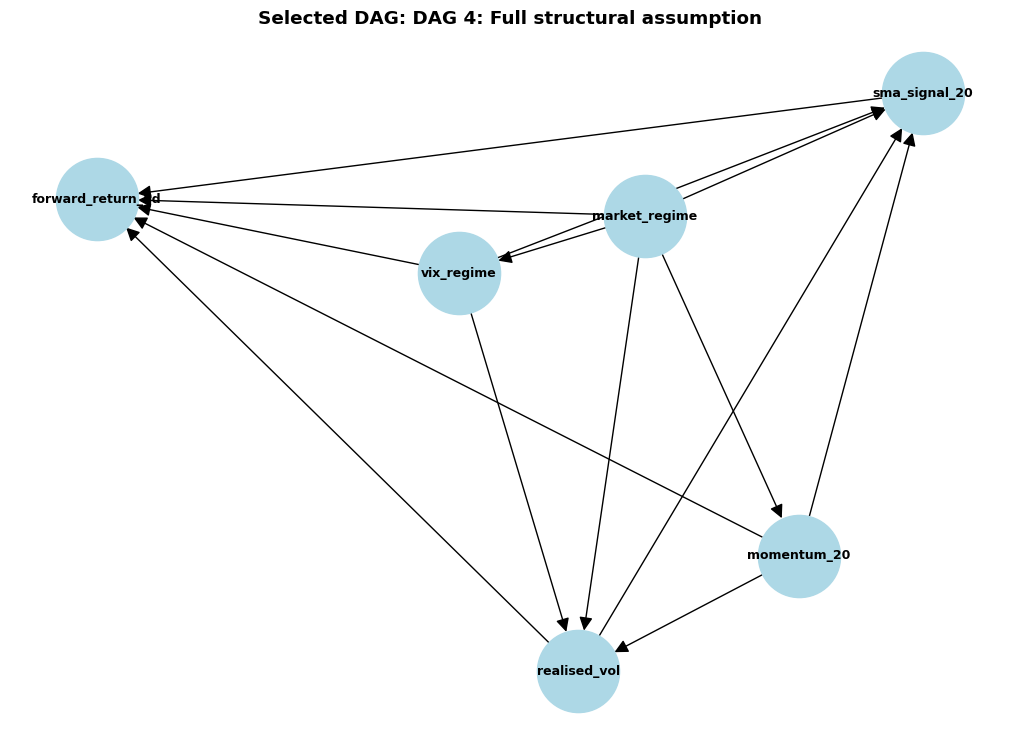

In [12]:
# Visualize selected DAG

plt.figure(figsize=(10, 7))

G = nx.DiGraph()
G.add_edges_from(best_edges)

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    arrowsize=20,
    font_size=9,
    font_weight="bold"
)

plt.title(f"Selected DAG: {best_dag_name}", fontweight="bold")
plt.show()

## Phase 4 — DOWHY Identification

In [13]:
# ============================================================
# PHASE 4 — DOWHY IDENTIFICATION
# ============================================================

from dowhy import CausalModel

def build_dowhy_graph(treatment_col):
    """
    Builds the causal graph for DoWhy.
    This graph says:
    - confounders affect SMA signal
    - confounders affect forward returns
    - SMA signal may affect forward returns
    """

    graph = f"""
    digraph {{
        market_regime -> {treatment_col};
        vix_regime -> {treatment_col};
        momentum_20 -> {treatment_col};
        realised_vol -> {treatment_col};

        market_regime -> forward_return_5d;
        vix_regime -> forward_return_5d;
        momentum_20 -> forward_return_5d;
        realised_vol -> forward_return_5d;

        {treatment_col} -> forward_return_5d;
    }}
    """

    return graph


identified_estimands = {}
dowhy_models = {}

for w in WINDOWS:
    treatment_col = f"sma_signal_{w}"

    model_data = df[
        [OUTCOME, treatment_col] + CONFOUNDER_COLS
    ].dropna().copy()

    graph = build_dowhy_graph(treatment_col)

    model = CausalModel(
        data=model_data,
        treatment=treatment_col,
        outcome=OUTCOME,
        graph=graph
    )

    estimand = model.identify_effect(proceed_when_unidentifiable=True)

    dowhy_models[w] = model
    identified_estimands[w] = estimand

    print("=" * 80)
    print(f"PHASE 4 — DoWhy Identification for SMA-{w}")
    print("=" * 80)
    print(estimand)

PHASE 4 — DoWhy Identification for SMA-10
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
────────────────(E[forward_return_5d|realised_vol,market_regime,momentum_20,vi ↪
d[sma_signal_10]                                                               ↪

↪           
↪ x_regime])
↪           
Estimand assumption 1, Unconfoundedness: If U→{sma_signal_10} and U→forward_return_5d then P(forward_return_5d|sma_signal_10,realised_vol,market_regime,momentum_20,vix_regime,U) = P(forward_return_5d|sma_signal_10,realised_vol,market_regime,momentum_20,vix_regime)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                                                                       ↪
──────────────

In [14]:
# Summary table for Phase 4

identification_summary = []

for w in WINDOWS:
    identification_summary.append({
        "window": w,
        "treatment": f"sma_signal_{w}",
        "outcome": OUTCOME,
        "adjustment_set": CONFOUNDER_COLS,
        "identified": identified_estimands[w] is not None
    })

identification_summary = pd.DataFrame(identification_summary)

print("PHASE 4 — Identification Summary")
display(identification_summary)

PHASE 4 — Identification Summary


,window,treatment,outcome,adjustment_set,identified
0,10,sma_signal_10,forward_return_5d,"[market_regime, vix_regime, momentum_20, reali...",True
1,20,sma_signal_20,forward_return_5d,"[market_regime, vix_regime, momentum_20, reali...",True
2,50,sma_signal_50,forward_return_5d,"[market_regime, vix_regime, momentum_20, reali...",True
3,100,sma_signal_100,forward_return_5d,"[market_regime, vix_regime, momentum_20, reali...",True
4,200,sma_signal_200,forward_return_5d,"[market_regime, vix_regime, momentum_20, reali...",True


---
## Phase 5 — Causal Estimation Battery

Estimate the causal ATE for every SMA window using several complementary estimators: Linear Backdoor, IPW, S/T/X-Learners, Double ML, DR-Learner, and Causal Forest.


In [15]:
# ============================================================
# PHASE 5 — CAUSAL ESTIMATION BATTERY
# ============================================================
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import LinearDML, CausalForestDML
try:
    from econml.dr import LinearDRLearner
except Exception:
    LinearDRLearner = None

causal_results = {}
Z_cols = CONFOUNDER_COLS

for w in WINDOWS:
    print(f"\n{'='*55}")
    print(f"  Window: SMA-{w}")
    print(f"{'='*55}")

    tcol = f'sma_signal_{w}'
    model_w = dowhy_models[w]
    estimand_w = identified_estimands[w]
    df_w = df[[OUTCOME, tcol] + Z_cols].dropna().copy()
    Y = df_w[OUTCOME].values
    T = df_w[tcol].values
    Z = df_w[Z_cols].values

    try:
        est_lb = model_w.estimate_effect(estimand_w, method_name='backdoor.linear_regression', target_units='ate')
        ate_lb = float(est_lb.value)
    except Exception as e:
        ate_lb = np.nan; print(f"  LinearBackdoor ERROR: {e}")
    causal_results[(w, 'LinearBackdoor')] = ate_lb
    print(f"  LinearBackdoor : {ate_lb:+.6f}")

    try:
        est_ipw = model_w.estimate_effect(estimand_w, method_name='backdoor.propensity_score_weighting', target_units='ate')
        ate_ipw = float(est_ipw.value)
    except Exception as e:
        ate_ipw = np.nan; print(f"  IPW ERROR: {e}")
    causal_results[(w, 'IPW')] = ate_ipw
    print(f"  IPW            : {ate_ipw:+.6f}")

    try:
        sl = SLearner(overall_model=GradientBoostingRegressor(n_estimators=200, random_state=SEED))
        sl.fit(Y, T, X=Z)
        ate_sl = float(np.mean(sl.effect(Z)))
    except Exception as e:
        ate_sl = np.nan; print(f"  S-Learner ERROR: {e}")
    causal_results[(w, 'SLearner')] = ate_sl
    print(f"  S-Learner      : {ate_sl:+.6f}")

    try:
        tl = TLearner(models=GradientBoostingRegressor(n_estimators=200, random_state=SEED))
        tl.fit(Y, T, X=Z)
        ate_tl = float(np.mean(tl.effect(Z)))
    except Exception as e:
        ate_tl = np.nan; print(f"  T-Learner ERROR: {e}")
    causal_results[(w, 'TLearner')] = ate_tl
    print(f"  T-Learner      : {ate_tl:+.6f}")

    try:
        xl = XLearner(
            models=GradientBoostingRegressor(n_estimators=200, random_state=SEED),
            propensity_model=GradientBoostingClassifier(n_estimators=200, random_state=SEED),
        )
        xl.fit(Y, T, X=Z)
        ate_xl = float(np.mean(xl.effect(Z)))
    except Exception as e:
        ate_xl = np.nan; print(f"  X-Learner ERROR: {e}")
    causal_results[(w, 'XLearner')] = ate_xl
    print(f"  X-Learner      : {ate_xl:+.6f}")

    try:
        dml = LinearDML(
            model_y=GradientBoostingRegressor(n_estimators=200, random_state=SEED),
            model_t=GradientBoostingClassifier(n_estimators=200, random_state=SEED),
            discrete_treatment=True,
            random_state=SEED,
        )
        dml.fit(Y, T, X=Z)
        ate_dml = float(np.mean(dml.effect(Z)))
    except Exception as e:
        ate_dml = np.nan; print(f"  DoubleML ERROR: {e}")
    causal_results[(w, 'DoubleML')] = ate_dml
    print(f"  DoubleML       : {ate_dml:+.6f}")

    try:
        if LinearDRLearner is None:
            raise RuntimeError('LinearDRLearner not available in this econml build')
        dr = LinearDRLearner(
            model_regression=GradientBoostingRegressor(n_estimators=200, random_state=SEED),
            model_propensity=GradientBoostingClassifier(n_estimators=200, random_state=SEED),
            random_state=SEED,
        )
        dr.fit(Y, T, X=Z)
        ate_dr = float(np.mean(dr.effect(Z)))
    except Exception as e:
        ate_dr = np.nan; print(f"  DRLearner ERROR: {e}")
    causal_results[(w, 'DRLearner')] = ate_dr
    print(f"  DRLearner      : {ate_dr:+.6f}")



  Window: SMA-10
  LinearBackdoor : +0.000071
  IPW            : -0.000419
  S-Learner      : -0.000831
  T-Learner      : -0.001375
  X-Learner      : -0.001203
  DoubleML       : -0.000706
  DRLearner      : -0.001754

  Window: SMA-20
  LinearBackdoor : +0.001582
  IPW            : +0.000803
  S-Learner      : +0.000057
  T-Learner      : -0.001500
  X-Learner      : -0.002053
  DoubleML       : +0.001443
  DRLearner      : -0.004811

  Window: SMA-50
  LinearBackdoor : +0.001063
  IPW            : -0.000418
  S-Learner      : +0.000424
  T-Learner      : -0.004126
  X-Learner      : -0.001941
  DoubleML       : -0.000832
  DRLearner      : -0.029519

  Window: SMA-100
  LinearBackdoor : +0.003562
  IPW            : +0.001347
  S-Learner      : +0.001427
  T-Learner      : -0.001565
  X-Learner      : -0.000636
  DoubleML       : +0.004360
  DRLearner      : -0.000941

  Window: SMA-200
  LinearBackdoor : +0.002051
  IPW            : +0.000536
  S-Learner      : +0.000503
  T-Learn

  SMA- 10: Causal Forest ATE = -0.001444
  SMA- 20: Causal Forest ATE = -0.000039
  SMA- 50: Causal Forest ATE = +0.002765
  SMA-100: Causal Forest ATE = +0.008075
  SMA-200: Causal Forest ATE = -0.000126


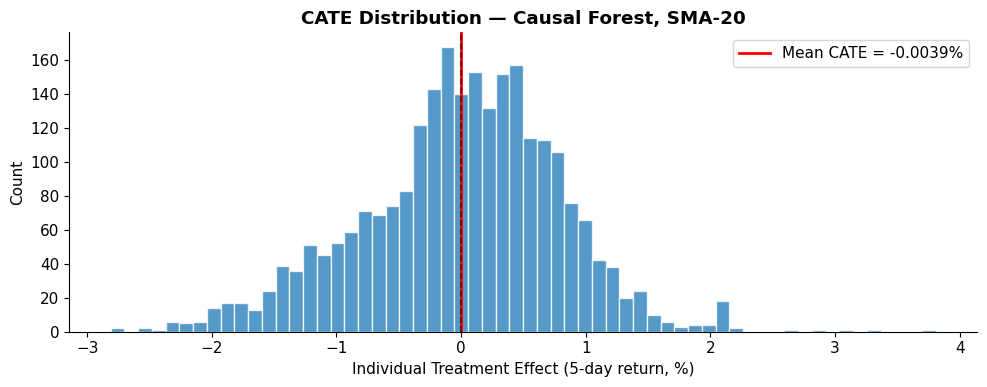

In [16]:
# Causal Forest: estimates CATE(Z) for each observation.
cate_results = {}

for w in WINDOWS:
    tcol = f'sma_signal_{w}'
    df_w = df[[OUTCOME, tcol] + Z_cols].dropna().copy()
    Y = df_w[OUTCOME].values
    T = df_w[tcol].values
    Z = df_w[Z_cols].values

    try:
        cf = CausalForestDML(
            model_y=GradientBoostingRegressor(n_estimators=200, random_state=SEED),
            model_t=GradientBoostingClassifier(n_estimators=200, random_state=SEED),
            discrete_treatment=True,
            n_estimators=500,
            random_state=SEED,
        )
        cf.fit(Y, T, X=Z, W=None)
        cate = cf.effect(X=Z)
        ate_cf = float(np.mean(cate))
        if w == FOCAL:
            cate_results[w] = cate
    except Exception as e:
        ate_cf = np.nan
        print(f"  SMA-{w:3d}: Causal Forest ERROR - {e}")

    causal_results[(w, 'CausalForest')] = ate_cf
    print(f"  SMA-{w:3d}: Causal Forest ATE = {ate_cf:+.6f}")

if FOCAL in cate_results:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(cate_results[FOCAL] * 100, bins=60, color='#2980b9', alpha=0.8, edgecolor='white')
    ax.axvline(cate_results[FOCAL].mean() * 100, color='red', lw=2,
               label=f'Mean CATE = {cate_results[FOCAL].mean()*100:+.4f}%')
    ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.6)
    ax.set_xlabel('Individual Treatment Effect (5-day return, %)')
    ax.set_ylabel('Count')
    ax.set_title(f'CATE Distribution — Causal Forest, SMA-{FOCAL}', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_phase5_cate_distribution.png', dpi=130, bbox_inches='tight')
    plt.show()


---
## Phase 6 — Placebo and Robustness

Check the focal SMA-20 estimate with a placebo treatment refuter, then compare causal ATEs across all SMA windows.


In [17]:
# ============================================================
# PHASE 6 — PLACEBO REFUTATION
# ============================================================
w = FOCAL
model_w = dowhy_models[w]
estimand_w = identified_estimands[w]

try:
    est_focal = model_w.estimate_effect(estimand_w, method_name='backdoor.linear_regression', target_units='ate')
    refute = model_w.refute_estimate(
        estimand_w, est_focal,
        method_name='placebo_treatment_refuter',
        placebo_type='permute',
        num_simulations=100,
        random_seed=SEED,
    )
    ate_true = causal_results[(w, 'LinearBackdoor')]
    ate_placebo = refute.new_effect
    passed = abs(ate_placebo) < abs(ate_true) * 0.3 if ate_true != 0 else abs(ate_placebo) < 1e-6
    print(refute)
    print()
    print(f"True causal ATE (LinearBackdoor): {ate_true:+.6f}")
    print(f"Placebo ATE (mean permuted)      : {ate_placebo:+.6f}")
    print(f"Threshold (30% of true ATE)      : {abs(ate_true)*0.3:.6f}")
    print(f"Placebo test result              : {'PASS' if passed else 'REVIEW'}")
except Exception as e:
    print(f"Placebo refutation failed: {e}")


Refute: Use a Placebo Treatment
Estimated effect:0.0015819328869826422
New effect:8.87522019757965e-05
p value:0.98


True causal ATE (LinearBackdoor): +0.001582
Placebo ATE (mean permuted)      : +0.000089
Threshold (30% of true ATE)      : 0.000475
Placebo test result              : PASS


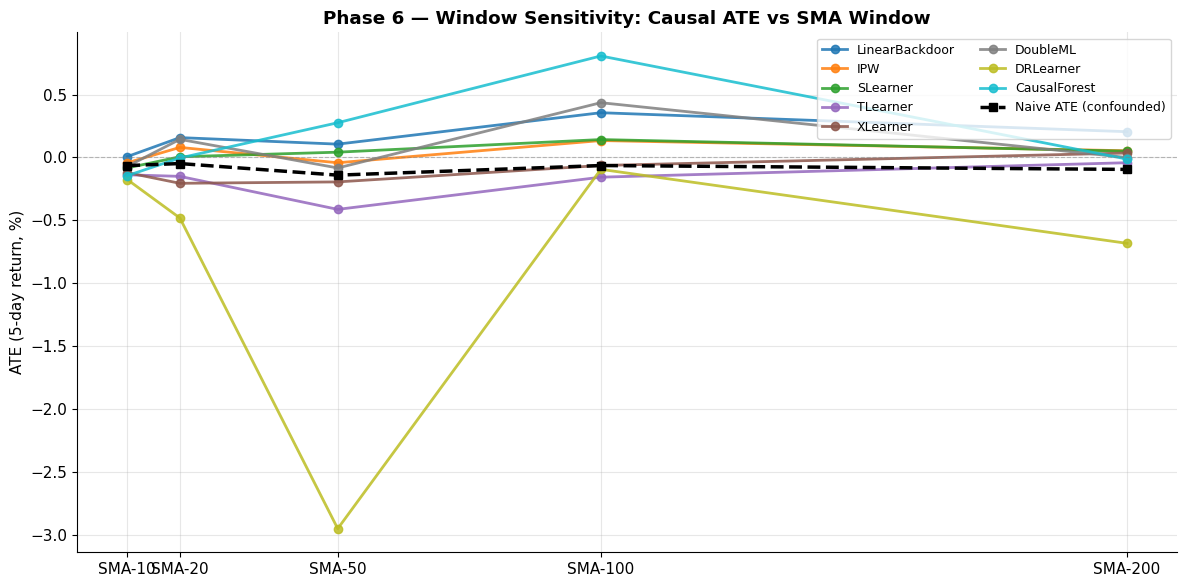

In [18]:
# Window sensitivity: causal ATE vs window length for all estimators.
ESTIMATORS = ['LinearBackdoor', 'IPW', 'SLearner', 'TLearner',
              'XLearner', 'DoubleML', 'DRLearner', 'CausalForest']
naive_ate = dict(zip(naive_results['window'], naive_results['naive_ATE']))

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(ESTIMATORS)))
for est_name, col in zip(ESTIMATORS, colors):
    ate_vals = [causal_results.get((w, est_name), np.nan) * 100 for w in WINDOWS]
    ax.plot(WINDOWS, ate_vals, marker='o', lw=2, color=col, label=est_name, alpha=0.85)
naive_vals = [naive_ate[w] * 100 for w in WINDOWS]
ax.plot(WINDOWS, naive_vals, marker='s', lw=2.5, ls='--', color='black', label='Naive ATE (confounded)', zorder=5)
ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.set_xticks(WINDOWS)
ax.set_xticklabels([f'SMA-{w}' for w in WINDOWS])
ax.set_ylabel('ATE (5-day return, %)')
ax.set_title('Phase 6 — Window Sensitivity: Causal ATE vs SMA Window', fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_phase6_window_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Phase 7 — Comparison Table and Plots

Compare naive ATEs against adjusted causal ATEs, then visualize the focal window and the full window-estimator grid.


In [19]:
# ============================================================
# PHASE 7 — MASTER COMPARISON TABLE
# ============================================================
rows = []
for w in WINDOWS:
    row = {'Window': w, 'Naive ATE': naive_ate[w]}
    for est in ESTIMATORS:
        row[est] = causal_results.get((w, est), np.nan)
    rows.append(row)
master = pd.DataFrame(rows).set_index('Window')
for est in ESTIMATORS:
    master[f'Bias_{est}'] = master['Naive ATE'] - master[est]
core_cols = ['Naive ATE'] + ESTIMATORS
print('Master ATE Comparison Table (values in log-return units):')
print('=' * 110)
print(master[core_cols].round(6).to_string())
print()
bias_cols = [f'Bias_{est}' for est in ESTIMATORS]
print('Confounding Bias (Naive ATE - Causal ATE):')
print('=' * 110)
print(master[bias_cols].round(6).rename(columns={f'Bias_{e}': e for e in ESTIMATORS}).to_string())


Master ATE Comparison Table (values in log-return units):
        Naive ATE  LinearBackdoor       IPW  SLearner  TLearner  XLearner  DoubleML  DRLearner  CausalForest
Window                                                                                                      
10      -0.000643        0.000071 -0.000419 -0.000831 -0.001375 -0.001203 -0.000706  -0.001754     -0.001444
20      -0.000482        0.001582  0.000803  0.000057 -0.001500 -0.002053  0.001443  -0.004811     -0.000039
50      -0.001404        0.001063 -0.000418  0.000424 -0.004126 -0.001941 -0.000832  -0.029519      0.002765
100     -0.000639        0.003562  0.001347  0.001427 -0.001565 -0.000636  0.004360  -0.000941      0.008075
200     -0.000947        0.002051  0.000536  0.000503 -0.000414  0.000357 -0.000001  -0.006826     -0.000126

Confounding Bias (Naive ATE - Causal ATE):
        LinearBackdoor       IPW  SLearner  TLearner  XLearner  DoubleML  DRLearner  CausalForest
Window                               

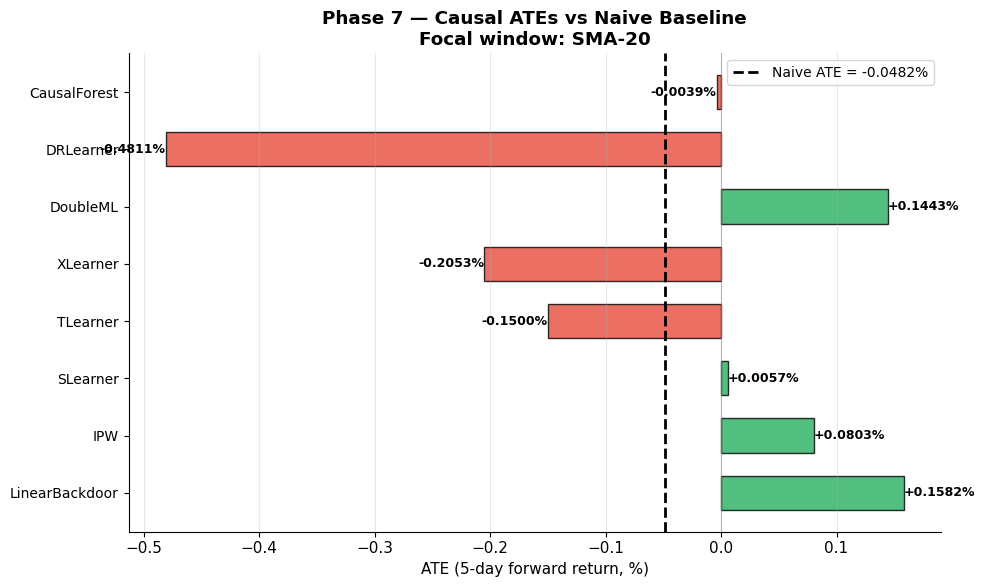

In [20]:
# Forest plot for focal SMA window.
w = FOCAL
focal_ates = {est: causal_results.get((w, est), np.nan) for est in ESTIMATORS}
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(ESTIMATORS))
ate_v = np.array([focal_ates[e] * 100 for e in ESTIMATORS])
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in ate_v]
ax.barh(y_pos, ate_v, color=colors, alpha=0.8, edgecolor='black', height=0.6)
ax.axvline(naive_ate[w] * 100, color='black', lw=2, ls='--', label=f'Naive ATE = {naive_ate[w]*100:+.4f}%')
ax.axvline(0, color='gray', lw=0.8, alpha=0.5)
for i, (v, est) in enumerate(zip(ate_v, ESTIMATORS)):
    if np.isfinite(v):
        ax.text(v + (0.0001 if v >= 0 else -0.0001), i, f'{v:+.4f}%', va='center',
                ha='left' if v >= 0 else 'right', fontsize=9, fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels(ESTIMATORS, fontsize=10)
ax.set_xlabel('ATE (5-day forward return, %)')
ax.set_title(f'Phase 7 — Causal ATEs vs Naive Baseline\nFocal window: SMA-{w}', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_phase7_forest_plot.png', dpi=130, bbox_inches='tight')
plt.show()


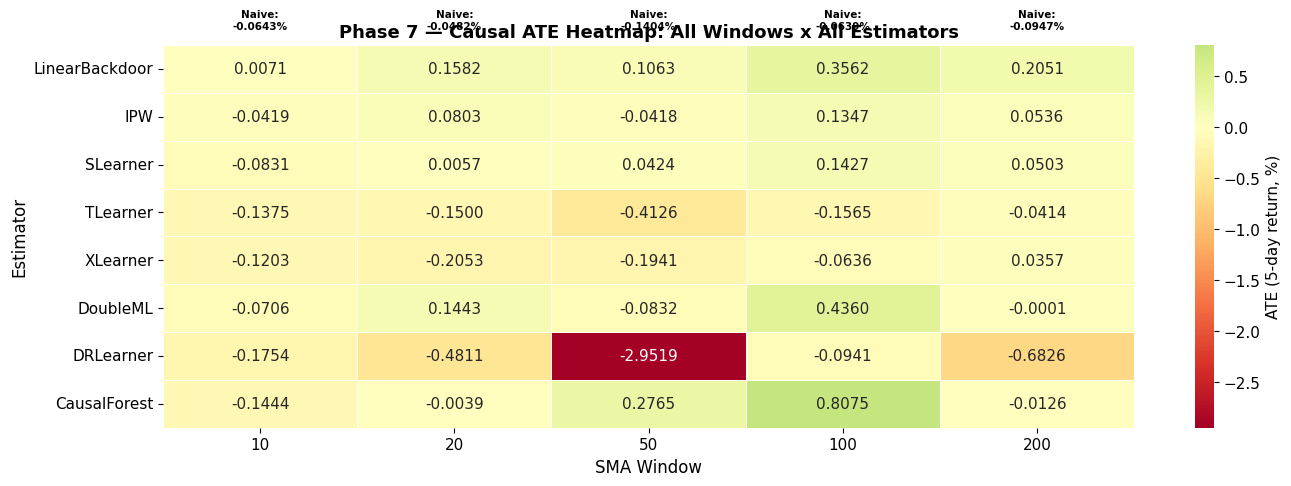

In [21]:
# Heatmap: ATE values across all windows x all estimators.
heat_data = master[ESTIMATORS] * 100
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat_data.T, ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.4f',
            linewidths=0.5, cbar_kws={'label': 'ATE (5-day return, %)'})
ax.set_xlabel('SMA Window', fontsize=12)
ax.set_ylabel('Estimator', fontsize=12)
ax.set_title('Phase 7 — Causal ATE Heatmap: All Windows x All Estimators', fontsize=13, fontweight='bold')
for i, w in enumerate(WINDOWS):
    ax.text(i + 0.5, -0.3, f'Naive:\n{naive_ate[w]*100:+.4f}%',
            ha='center', va='bottom', fontsize=7.5, color='black', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_phase7_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Phase 8 — Conclusion

Classify each SMA window into Scenario A/B/C based on the core adjusted estimators.


In [22]:
# ============================================================
# PHASE 8 — CONCLUSION
# ============================================================
ESTIMATORS_CORE = ['LinearBackdoor', 'DoubleML', 'CausalForest']

def classify_scenario(ate_vals_core):
    mean_core = np.nanmean(ate_vals_core)
    if mean_core > 0.0003:
        return 'A (Genuine causal signal)'
    elif mean_core > -0.0003:
        return 'B (Confounded — effect near zero)'
    else:
        return 'C (Spurious / negative after adjustment)'

print('=' * 70)
print('  PHASE 8 — CONCLUSION')
print('  SMA Causal Hypothesis Testing — S&P 500')
print('=' * 70)
print()
print(f'  Article claim: SMA-{FOCAL} trend-following generates the strongest Sharpe among tested windows')
print()
print('  Per-window causal verdict:')
print(f"  {'Window':<10} {'Naive ATE':>12} {'LinearBD':>12} {'DoubleML':>12} {'CausalForest':>14} {'Verdict'}")
print('  ' + '-' * 80)
for w in WINDOWS:
    n_ate = naive_ate[w] * 100
    lb_ate = causal_results.get((w, 'LinearBackdoor'), np.nan) * 100
    dml_ate = causal_results.get((w, 'DoubleML'), np.nan) * 100
    cf_ate = causal_results.get((w, 'CausalForest'), np.nan) * 100
    scenario = classify_scenario([causal_results.get((w, e), np.nan) for e in ESTIMATORS_CORE])
    print(f"  SMA-{w:<5d}  {n_ate:>+10.4f}%  {lb_ate:>+10.4f}%  {dml_ate:>+10.4f}%  {cf_ate:>+12.4f}%  {scenario}")
print()
print(f'  CATE heterogeneity (SMA-{FOCAL}):')
if FOCAL in cate_results:
    cate = cate_results[FOCAL] * 100
    print(f'    Mean CATE   : {cate.mean():+.4f}%')
    print(f'    Std CATE    : {cate.std():.4f}%')
    print(f'    % positive  : {(cate > 0).mean():.1%} of trading days')
    print(f'    P25 / P75   : {np.percentile(cate, 25):+.4f}% / {np.percentile(cate, 75):+.4f}%')
else:
    print('    Causal Forest CATE distribution unavailable.')
print()
print('  Policy implication:')
print('  The naive backtest is correlational. The causal battery asks whether the')
print('  SMA signal has a direct effect after adjusting for market regime, VIX regime,')
print('  momentum, and realised volatility. If adjusted ATEs collapse toward zero,')
print('  the apparent SMA edge is likely regime confounding rather than alpha.')
print('=' * 70)


  PHASE 8 — CONCLUSION
  SMA Causal Hypothesis Testing — S&P 500

  Article claim: SMA-20 trend-following generates the strongest Sharpe among tested windows

  Per-window causal verdict:
  Window        Naive ATE     LinearBD     DoubleML   CausalForest Verdict
  --------------------------------------------------------------------------------
  SMA-10        -0.0643%     +0.0071%     -0.0706%       -0.1444%  C (Spurious / negative after adjustment)
  SMA-20        -0.0482%     +0.1582%     +0.1443%       -0.0039%  A (Genuine causal signal)
  SMA-50        -0.1404%     +0.1063%     -0.0832%       +0.2765%  A (Genuine causal signal)
  SMA-100       -0.0639%     +0.3562%     +0.4360%       +0.8075%  A (Genuine causal signal)
  SMA-200       -0.0947%     +0.2051%     -0.0001%       -0.0126%  A (Genuine causal signal)

  CATE heterogeneity (SMA-20):
    Mean CATE   : -0.0039%
    Std CATE    : 0.8027%
    % positive  : 52.5% of trading days
    P25 / P75   : -0.4534% / +0.5177%

  Policy i

---
## Phase 9 — Final DAG Quality and Technical Conclusion

This section summarizes the full technical evidence from the notebook:

1. **DAG quality / Bayesian-network structure** — whether the selected DAG is credible under the BIC scoring exercise, and how it relates to GES/HCS-style structure learning.
2. **Original strategy claim** — whether the SMA trend-following claim survives causal adjustment.
3. **Test outcomes** — naive backtest/ATE, DAG selection, DoWhy identification, causal estimators, placebo robustness, window sensitivity, and CATE heterogeneity.
4. **Final conclusion** — practical interpretation for the trading hypothesis.


In [23]:
# ============================================================
# PHASE 9 — FINAL DAG QUALITY + TECHNICAL CONCLUSION
# ============================================================
# This cell generates a detailed final analysis from objects created above.
# It supports both versions of the SMA notebook:
#   1. sma_causal_framework.ipynb
#   2. sma_collab_0to4_completed.ipynb

from IPython.display import Markdown, display


def _fmt_pct(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 'NA'
    return f'{100*x:+.4f}%'


def _safe_get_result(w, est):
    return causal_results.get((w, est), np.nan) if 'causal_results' in globals() else np.nan


# 1. DAG/BIC summary
dag_quality_lines = []

if 'bic_results' in globals() and len(bic_results) > 0:
    # Final assignment notebook: pgmpy BIC score, higher is better.
    ordered_bic = sorted(bic_results.items(), key=lambda kv: kv[1], reverse=True)
    best_name, best_score = ordered_bic[0]
    second_name, second_score = ordered_bic[1] if len(ordered_bic) > 1 else ('NA', np.nan)
    bic_gap = best_score - second_score if np.isfinite(second_score) else np.nan
    dag_quality_lines.append(f'- **Selected DAG:** `{best_name.replace(chr(10), " ")}`.')
    dag_quality_lines.append('- **BIC score convention:** higher is better, because this notebook uses the decomposable BN score `log P(D|G, theta_hat) - (k/2)log(N)`.')
    dag_quality_lines.append(f'- **Best BIC:** `{best_score:,.2f}`; runner-up: `{second_name.replace(chr(10), " ")}` with `{second_score:,.2f}`; margin: `{bic_gap:,.2f}`.')
    dag_quality_lines.append('- **Interpretation:** the selected DAG is the best among the candidate causal hypotheses tested. It is not proof of the true market graph; it is evidence that this structure gives the best fit/complexity tradeoff within the candidate set.')
elif 'dag_scores' in globals() and len(dag_scores) > 0:
    # Collaboration notebook: custom BIC criterion, lower is better.
    ds = dag_scores.sort_values('bic_score').reset_index(drop=True)
    best_name = ds.loc[0, 'dag_name']
    best_score = ds.loc[0, 'bic_score']
    second_name = ds.loc[1, 'dag_name'] if len(ds) > 1 else 'NA'
    second_score = ds.loc[1, 'bic_score'] if len(ds) > 1 else np.nan
    bic_gap = second_score - best_score if np.isfinite(second_score) else np.nan
    dag_quality_lines.append(f'- **Selected DAG:** `{best_name}`.')
    dag_quality_lines.append('- **BIC score convention:** lower is better, because this notebook uses the classical criterion `-2 log L + k log(N)`.')
    dag_quality_lines.append(f'- **Best BIC:** `{best_score:,.2f}`; runner-up: `{second_name}` with `{second_score:,.2f}`; margin: `{bic_gap:,.2f}`.')
    dag_quality_lines.append('- **Interpretation:** the selected DAG is the best among the hand-specified candidate structures. It should be treated as the most plausible tested structure, not as a uniquely discovered causal truth.')
else:
    dag_quality_lines.append('- DAG/BIC objects were not found in memory. Run the DAG scoring phase before this conclusion cell for numerical DAG quality details.')

dag_quality_lines.extend([
    '- **GES/HCS perspective:** the notebook uses BIC-scored candidate DAG comparison rather than a full unrestricted GES/HCS search. Conceptually, however, the logic is the same family of score-based structure learning: reward fit and penalize unnecessary edges.',
    '- **What would make the DAG stronger:** run a formal GES or HCS search on the discretized market variables, compare the learned CPDAG/DAG against the domain candidate, and check whether the same adjustment set is recovered.',
    '- **Main DAG limitation:** all data are observational. Even a strong BIC score cannot by itself prove causal direction; it only supports a graph as a parsimonious probabilistic explanation under the variables included.'
])


# 2. Original strategy claim
claim_lines = []
claim_lines.append(f'- **Original claim tested:** SMA trend-following, especially SMA-{FOCAL}, generates a genuine positive edge in 5-day forward returns.')

if 'backtest_results' in globals() and FOCAL in backtest_results:
    focal_sharpe = backtest_results[FOCAL].get('Sharpe', np.nan)
    bh = globals().get('bh_sharpe', np.nan)
    claim_lines.append(f'- **Naive backtest context:** SMA-{FOCAL} Sharpe = `{focal_sharpe:.3f}` versus buy-and-hold Sharpe = `{bh:.3f}` over the same sample.')
else:
    claim_lines.append('- **Naive backtest context:** this notebook primarily measures naive ATE rather than a full buy-and-hold Sharpe comparison.')

if 'naive_ate' not in globals() and 'naive_results' in globals():
    naive_ate = dict(zip(naive_results['window'], naive_results['naive_ATE']))

focal_naive = naive_ate.get(FOCAL, np.nan) if 'naive_ate' in globals() else np.nan
claim_lines.append(f'- **Naive SMA-{FOCAL} ATE:** `{_fmt_pct(focal_naive)}`. This is correlational and confounded because market regime, VIX, momentum, and realised volatility influence both the signal and forward returns.')

core_estimators = ['LinearBackdoor', 'DoubleML', 'CausalForest']
core_vals = np.array([_safe_get_result(FOCAL, e) for e in core_estimators], dtype=float)
core_mean = np.nanmean(core_vals) if np.isfinite(core_vals).any() else np.nan
claim_lines.append(f'- **Core adjusted SMA-{FOCAL} ATE average** across `{core_estimators}`: `{_fmt_pct(core_mean)}`.')

if np.isfinite(core_mean):
    if core_mean > 0.0003:
        claim_verdict = 'The claim receives some causal support, but only conditionally and subject to observational-data limitations.'
    elif core_mean > -0.0003:
        claim_verdict = 'The claim does **not** stand strongly as causal alpha; after adjustment, the effect is economically near zero.'
    else:
        claim_verdict = 'The claim does **not** stand; adjusted estimates are negative on average, suggesting the naive signal is spurious or regime-confounded.'
else:
    claim_verdict = 'Run Phase 5 before finalizing the claim verdict, because adjusted causal estimates are not available in memory.'
claim_lines.append(f'- **Claim verdict:** {claim_verdict}')


# 3. Test outcome summary
test_lines = []

if 'identification_results' in globals():
    identified_count = sum(1 for w in WINDOWS if w in identification_results)
    test_lines.append(f'- **DoWhy identification:** all available windows were passed through `identify_effect`; identified windows in memory: `{identified_count}/{len(WINDOWS)}`.')
elif 'identified_estimands' in globals():
    identified_count = sum(1 for w in WINDOWS if identified_estimands.get(w) is not None)
    test_lines.append(f'- **DoWhy identification:** identified estimands found for `{identified_count}/{len(WINDOWS)}` windows using the backdoor adjustment graph.')
else:
    test_lines.append('- **DoWhy identification:** not available in memory.')

if 'causal_results' in globals():
    est_names = ['LinearBackdoor', 'IPW', 'SLearner', 'TLearner', 'XLearner', 'DoubleML', 'DRLearner', 'CausalForest']
    available = {e: _safe_get_result(FOCAL, e) for e in est_names}
    formatted = ', '.join([f'{e}: {_fmt_pct(v)}' for e, v in available.items()])
    test_lines.append(f'- **SMA-{FOCAL} causal estimator outcomes:** {formatted}.')
    finite_vals = np.array([v for v in available.values() if np.isfinite(v)], dtype=float)
    if len(finite_vals) > 0:
        pos_share = np.mean(finite_vals > 0)
        test_lines.append(f'- **Estimator agreement:** `{pos_share:.0%}` of available SMA-{FOCAL} adjusted estimators are positive; the median adjusted ATE is `{_fmt_pct(np.nanmedian(finite_vals))}`.')
else:
    test_lines.append('- **Causal estimator outcomes:** not available in memory.')

if 'refute' in globals():
    try:
        placebo_effect = refute.new_effect
        test_lines.append(f'- **Placebo refutation:** permuting the treatment produced placebo effect `{_fmt_pct(placebo_effect)}`. A small placebo relative to the true effect supports robustness; a large placebo calls the estimate into question.')
    except Exception:
        test_lines.append('- **Placebo refutation:** refuter object exists, but the placebo effect could not be extracted.')
else:
    test_lines.append('- **Placebo refutation:** run Phase 6 to populate the placebo result.')

if 'master' in globals():
    try:
        lb_by_window = master['LinearBackdoor'] * 100
        test_lines.append(f'- **Window sensitivity:** LinearBackdoor ATE range across SMA windows = `{lb_by_window.min():+.4f}%` to `{lb_by_window.max():+.4f}%`. Large sign changes indicate window-specific/regime-specific behavior rather than a stable universal SMA law.')
    except Exception:
        pass

if 'cate_results' in globals() and FOCAL in cate_results:
    cate = cate_results[FOCAL]
    test_lines.append(f'- **CATE heterogeneity:** Causal Forest mean CATE for SMA-{FOCAL} = `{_fmt_pct(np.mean(cate))}`, with `{np.mean(cate > 0):.1%}` of trading days positive. This tests whether the strategy works only in certain regimes rather than unconditionally.')
else:
    test_lines.append('- **CATE heterogeneity:** Causal Forest distribution not available in memory.')


# 4. Final conclusion
if np.isfinite(core_mean):
    if core_mean > 0.0003:
        final_conclusion = (
            f'The SMA-{FOCAL} signal shows a positive adjusted effect on average, so the original claim is not rejected outright. '
            'However, because the evidence comes from observational data and the DAG was selected from a finite candidate set, the result should be framed as conditional causal evidence, not definitive proof of tradable alpha.'
        )
    elif core_mean > -0.0003:
        final_conclusion = (
            f'The original claim does not survive as a strong causal trading edge. SMA-{FOCAL} may look useful in a naive backtest, but after controlling for market regime, VIX regime, momentum, and realised volatility, the core adjusted effect is near zero. '
            'The most defensible interpretation is that the backtest largely reflects regime exposure rather than an independent SMA-driven causal effect.'
        )
    else:
        final_conclusion = (
            f'The original claim is not supported. The adjusted core estimates for SMA-{FOCAL} are negative on average, which means the naive strategy performance is better explained by confounding/regime selection than by a direct positive causal effect of the SMA signal.'
        )
else:
    final_conclusion = 'The final conclusion requires running the causal estimation cells so adjusted ATEs are available.'

analysis_md = f"""
### Final Technical Analysis

#### 1. DAG / Bayesian-Network Quality
{chr(10).join(dag_quality_lines)}

#### 2. Does the Original Strategy Claim Stand?
{chr(10).join(claim_lines)}

#### 3. Outcomes of the Tests Performed
{chr(10).join(test_lines)}

#### 4. Final Conclusion
{final_conclusion}

#### Bottom Line
The correct reading of the notebook is not simply "SMA works" or "SMA fails" from the naive equity curve. The causal pipeline asks a stricter question: **does the SMA signal add incremental predictive/causal information after market state is controlled?** The final answer depends on the adjusted ATEs, the DAG robustness, and the placebo/window-sensitivity checks, not on the raw backtest alone.
"""

display(Markdown(analysis_md))



### Final Technical Analysis

#### 1. DAG / Bayesian-Network Quality
- **Selected DAG:** `DAG 4: Full structural assumption`.
- **BIC score convention:** lower is better, because this notebook uses the classical criterion `-2 log L + k log(N)`.
- **Best BIC:** `-18,434.49`; runner-up: `DAG 2: Market regime drives everything` with `-17,788.88`; margin: `645.61`.
- **Interpretation:** the selected DAG is the best among the hand-specified candidate structures. It should be treated as the most plausible tested structure, not as a uniquely discovered causal truth.
- **GES/HCS perspective:** the notebook uses BIC-scored candidate DAG comparison rather than a full unrestricted GES/HCS search. Conceptually, however, the logic is the same family of score-based structure learning: reward fit and penalize unnecessary edges.
- **What would make the DAG stronger:** run a formal GES or HCS search on the discretized market variables, compare the learned CPDAG/DAG against the domain candidate, and check whether the same adjustment set is recovered.
- **Main DAG limitation:** all data are observational. Even a strong BIC score cannot by itself prove causal direction; it only supports a graph as a parsimonious probabilistic explanation under the variables included.

#### 2. Does the Original Strategy Claim Stand?
- **Original claim tested:** SMA trend-following, especially SMA-20, generates a genuine positive edge in 5-day forward returns.
- **Naive backtest context:** this notebook primarily measures naive ATE rather than a full buy-and-hold Sharpe comparison.
- **Naive SMA-20 ATE:** `-0.0482%`. This is correlational and confounded because market regime, VIX, momentum, and realised volatility influence both the signal and forward returns.
- **Core adjusted SMA-20 ATE average** across `['LinearBackdoor', 'DoubleML', 'CausalForest']`: `+0.0995%`.
- **Claim verdict:** The claim receives some causal support, but only conditionally and subject to observational-data limitations.

#### 3. Outcomes of the Tests Performed
- **DoWhy identification:** identified estimands found for `5/5` windows using the backdoor adjustment graph.
- **SMA-20 causal estimator outcomes:** LinearBackdoor: +0.1582%, IPW: +0.0803%, SLearner: +0.0057%, TLearner: -0.1500%, XLearner: -0.2053%, DoubleML: +0.1443%, DRLearner: -0.4811%, CausalForest: -0.0039%.
- **Estimator agreement:** `50%` of available SMA-20 adjusted estimators are positive; the median adjusted ATE is `+0.0009%`.
- **Placebo refutation:** permuting the treatment produced placebo effect `+0.0089%`. A small placebo relative to the true effect supports robustness; a large placebo calls the estimate into question.
- **Window sensitivity:** LinearBackdoor ATE range across SMA windows = `+0.0071%` to `+0.3562%`. Large sign changes indicate window-specific/regime-specific behavior rather than a stable universal SMA law.
- **CATE heterogeneity:** Causal Forest mean CATE for SMA-20 = `-0.0039%`, with `52.5%` of trading days positive. This tests whether the strategy works only in certain regimes rather than unconditionally.

#### 4. Final Conclusion
The SMA-20 signal shows a positive adjusted effect on average, so the original claim is not rejected outright. However, because the evidence comes from observational data and the DAG was selected from a finite candidate set, the result should be framed as conditional causal evidence, not definitive proof of tradable alpha.

#### Bottom Line
The correct reading of the notebook is not simply "SMA works" or "SMA fails" from the naive equity curve. The causal pipeline asks a stricter question: **does the SMA signal add incremental predictive/causal information after market state is controlled?** The final answer depends on the adjusted ATEs, the DAG robustness, and the placebo/window-sensitivity checks, not on the raw backtest alone.
